## PDA03 Module 8.1: Exploring Student Performance Data Analysis Assignment

### Task 0: Create the student performance dataset

In [19]:
# Not required because it has already been provided

# '''
# # Run the code to generate the file
# np.random.seed(0)
# num_samples = 1000
#
# # Generate random scores between 0 and 100 for each subject
# math_scores = np.random.randint(0, 101, num_samples)
# science_scores = np.random.randint(0, 101, num_samples)
# english_scores = np.random.randint(0, 101, num_samples)
#
# # Create a DataFrame
# df = pd.DataFrame(
#     {
# 'Math': math_scores,
# 'Science': science_scores,
# 'English': english_scores
# })
#
# # Save the DataFrame to a CSV file
# df.to_csv('student_performance.csv', index=False)
# '''

### Task 1: Import the necessary libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Task 2: Load the dataset

In [21]:
# Use Pandas to read the provided CSV file
df = pd.read_csv('.\\sample_data\\student_scores_2000_rows.csv')
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [22]:
# Convert the DataFrame to a NumPy array for numerical analysis
scores_array = df.to_numpy()
scores_array

array([[1, 'Paul', 'Casey', ..., 63, 80, 87],
       [2, 'Danielle', 'Sandoval', ..., 90, 88, 90],
       [3, 'Tina', 'Andrews', ..., 65, 77, 94],
       ...,
       [1998, 'Madison', 'Cross', ..., 68, 94, 78],
       [1999, 'Brittany', 'Compton', ..., 95, 88, 75],
       [2000, 'Natalie', 'Smith', ..., 83, 93, 100]],
      shape=(2000, 17), dtype=object)

### Task 3: Data cleaning

In [23]:
# Check for any missing or null values and handle them appropriately
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [24]:
missing_values = df.isnull().sum().sum()

if missing_values == 0:
    print("*** No missing values found ***")
else:
    print(f"*** {missing_values} missing value(s) found. Please handle appropriately ***")


*** No missing values found ***


In [25]:
# There are no missing values

# If there were any missing values, we could handle them either by filling them with the mean/median or by dropping the rows with missing values

# We can proceed to ensure all data types are correct
print(df.dtypes)

id                             int64
first_name                    object
last_name                     object
email                         object
gender                        object
part_time_job                   bool
absence_days                   int64
extracurricular_activities      bool
weekly_self_study_hours        int64
career_aspiration             object
math_score                     int64
history_score                  int64
physics_score                  int64
chemistry_score                int64
biology_score                  int64
english_score                  int64
geography_score                int64
dtype: object


In [26]:
# Ensure all data types are correct (scores should be numeric)
df_scores = df[[col for col in df.columns if "score" in col]]

if df_scores.dtypes.eq('int64').all():
    print("*** All data types are correct ***")
else:
    print("*** Data type issues found. Please ensure all scores are numeric ***")

*** All data types are correct ***


In [27]:
# If there were any non-numeric data types for the scores, we could convert them to numeric using pd.to_numeric() or handle them accordingly

# After handling any missing values and non-numeric data types, it would then also be necessary to again convert the DataFrame to a NumPy array for numerical analysis
scores_array = df_scores.to_numpy()
scores_array

array([[ 73,  81,  93, ...,  63,  80,  87],
       [ 90,  86,  96, ...,  90,  88,  90],
       [ 81,  97,  95, ...,  65,  77,  94],
       ...,
       [ 97,  85,  63, ...,  68,  94,  78],
       [ 51,  96,  72, ...,  95,  88,  75],
       [ 82,  99,  91, ...,  83,  93, 100]], shape=(2000, 7))

### Task 4: Exploratory data analysis (EDA)

In [28]:
# Now the dataset is clean and ready for analysis

# Calculate descriptive statistics for each subject: mean, median, mode, range, variance, and standard deviation

# This can be done using the describe() method of Pandas DataFrame

summary_stats = df_scores.describe()
print(summary_stats)

for col in summary_stats.columns:
    mean_val = df_scores[col].mean()
    median_val = df_scores[col].median()
    mode_val = df_scores[col].mode().iloc[0]
    range_val = df_scores[col].max() - df_scores[col].min()
    variance_val = df_scores[col].var()
    std_val = df_scores[col].std()

    print("\n")
    print(f"Descriptive statistics for {col}:")
    print(f"Mean: {mean_val}")
    print(f"Median: {median_val}")
    print(f"Mode: {mode_val}")
    print(f"Range: {range_val}")
    print(f"Variance: {variance_val}")
    print(f"Standard deviation: {std_val}")

# Determine the subject with the highest variance in scores
highest_variance_subject = df_scores.var().idxmax()
print("\n")
print(f"The subject with the highest variance in scores is: {highest_variance_subject}"
      f"\nWith a variance of: {df_scores.var().max()}")


        math_score  history_score  physics_score  chemistry_score  \
count  2000.000000    2000.000000    2000.000000      2000.000000   
mean     83.452000      80.332000      81.336500        79.995000   
std      13.224906      12.736046      12.539453        12.777895   
min      40.000000      50.000000      50.000000        50.000000   
25%      77.000000      69.750000      71.000000        69.000000   
50%      87.000000      82.000000      83.000000        81.000000   
75%      93.000000      91.000000      92.000000        91.000000   
max     100.000000     100.000000     100.000000       100.000000   

       biology_score  english_score  geography_score  
count     2000.00000    2000.000000      2000.000000  
mean        79.58150      81.277500        80.888000  
std         13.72219      12.027087        11.637705  
min         30.00000      50.000000        60.000000  
25%         69.00000      72.000000        71.000000  
50%         81.00000      83.000000        81.00

In [29]:
# Calculate descriptive statistics for each subject: mean, median, mode, range, variance, and standard deviation

# This can also be done using NumPy functions directly on the NumPy array

means = np.mean(scores_array, axis=0)
medians = np.median(scores_array, axis=0)

# NumPy doesn't have a mode function, but SciPy does, and it can operate on a NumPy array
from scipy import stats
modes = stats.mode(scores_array, axis=0)[0]

ranges = np.ptp(scores_array, axis=0)
variances = np.var(scores_array, axis=0)
stds = np.std(scores_array, axis=0)

desc_stats_dict = {
    'subject': df_scores.columns.to_numpy(),
    'mean': means,
    'median': medians,
    'mode': modes,
    'range':ranges,
    'variance': variances,
    'std': stds}

for i, subject in enumerate(desc_stats_dict['subject']):
    print("\n")
    print(f"Descriptive statistics for {subject}:")
    print(f"Mean: {desc_stats_dict['mean'][i]}")
    print(f"Median: {desc_stats_dict['median'][i]}")
    print(f"Mode: {desc_stats_dict['mode'][i]}")
    print(f"Range: {desc_stats_dict['range'][i]}")
    print(f"Variance: {desc_stats_dict['variance'][i]}")
    print(f"Standard deviation: {desc_stats_dict['std'][i]}")

# Determine the subject with the highest variance in scores
numpy_highest_variance_subject = desc_stats_dict['subject'][np.argmax(desc_stats_dict['variance'])]
print("\n")
print(f"The subject with the highest variance in scores is: {numpy_highest_variance_subject}"
      f"\nWith a variance of: {np.max(desc_stats_dict['variance'])}")



Descriptive statistics for math_score:
Mean: 83.452
Median: 87.0
Mode: 99
Range: 60
Variance: 174.810696
Standard deviation: 13.22159960065347


Descriptive statistics for history_score:
Mean: 80.332
Median: 82.0
Mode: 88
Range: 50
Variance: 162.125776
Standard deviation: 12.73286205061533


Descriptive statistics for physics_score:
Mean: 81.3365
Median: 83.0
Mode: 96
Range: 50
Variance: 157.15926775
Standard deviation: 12.536317950259559


Descriptive statistics for chemistry_score:
Mean: 79.995
Median: 81.0
Mode: 94
Range: 50
Variance: 163.19297500000002
Standard deviation: 12.774700583575335


Descriptive statistics for biology_score:
Mean: 79.5815
Median: 81.0
Mode: 100
Range: 70
Variance: 188.20435775
Standard deviation: 13.718759337126663


Descriptive statistics for english_score:
Mean: 81.2775
Median: 83.0
Mode: 90
Range: 49
Variance: 144.57849375
Standard deviation: 12.024079746492037


Descriptive statistics for geography_score:
Mean: 80.888
Median: 81.0
Mode: 88
Range: 40


In [30]:
# Compare the descriptive statistics obtained from Pandas and NumPy

# This can be done by comparing the values obtained from both methods for each statistic and subject

for i, subject in enumerate(desc_stats_dict['subject']):
    print("\n")

    print(f"Comparing descriptive statistics for {subject}:")

    print(f"Mean: Pandas = {summary_stats.loc['mean', subject]}, "
          f"NumPy = {desc_stats_dict['mean'][i]}")

    print(f"Median: Pandas = {summary_stats.loc['50%', subject]}, "
          f"NumPy = {desc_stats_dict['median'][i]}")

    print(f"Mode: Pandas = {df_scores[subject].mode().iloc[0]}, "
          f"NumPy = {desc_stats_dict['mode'][i]}")

    print(f"Range: Pandas = {summary_stats.loc['max', subject] - summary_stats.loc['min', subject]}, "
          f"NumPy = {desc_stats_dict['range'][i]}")

    print(f"Variance: Pandas = {df_scores[subject].var()}, "
          f"NumPy = {desc_stats_dict['variance'][i]}")

    print(f"Standard deviation: Pandas = {summary_stats.loc['std', subject]}, "
          f"NumPy = {desc_stats_dict['std'][i]}")

# The values obtained from both methods should match closely, confirming the consistency of the descriptive statistics calculated using Pandas and NumPy

# Variance and standard deviation values may differ slightly due to the default degrees of freedom used in Pandas (ddof=1) vs NumPy (ddof=0)

# To ensure they match, we can specify ddof=1 in the NumPy calculations for variance and standard deviation



Comparing descriptive statistics for math_score:
Mean: Pandas = 83.452, NumPy = 83.452
Median: Pandas = 87.0, NumPy = 87.0
Mode: Pandas = 99, NumPy = 99
Range: Pandas = 60.0, NumPy = 60
Variance: Pandas = 174.89814507253627, NumPy = 174.810696
Standard deviation: Pandas = 13.22490624059529, NumPy = 13.22159960065347


Comparing descriptive statistics for history_score:
Mean: Pandas = 80.332, NumPy = 80.332
Median: Pandas = 82.0, NumPy = 82.0
Mode: Pandas = 88, NumPy = 88
Range: Pandas = 50.0, NumPy = 50
Variance: Pandas = 162.20687943971987, NumPy = 162.125776
Standard deviation: Pandas = 12.736046460331396, NumPy = 12.73286205061533


Comparing descriptive statistics for physics_score:
Mean: Pandas = 81.3365, NumPy = 81.3365
Median: Pandas = 83.0, NumPy = 83.0
Mode: Pandas = 96, NumPy = 96
Range: Pandas = 50.0, NumPy = 50
Variance: Pandas = 157.23788669334667, NumPy = 157.15926775
Standard deviation: Pandas = 12.539453205516844, NumPy = 12.536317950259559


Comparing descriptive sta

### Task 5: Data visualisation

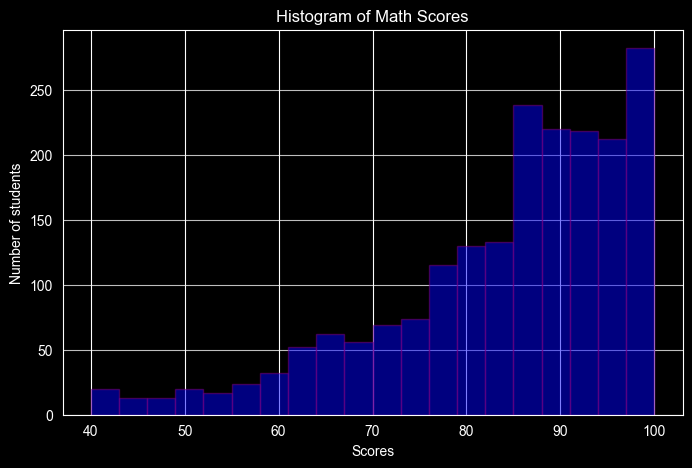

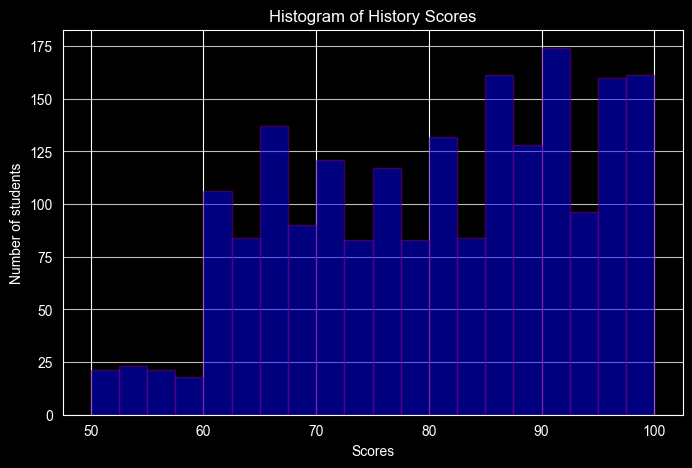

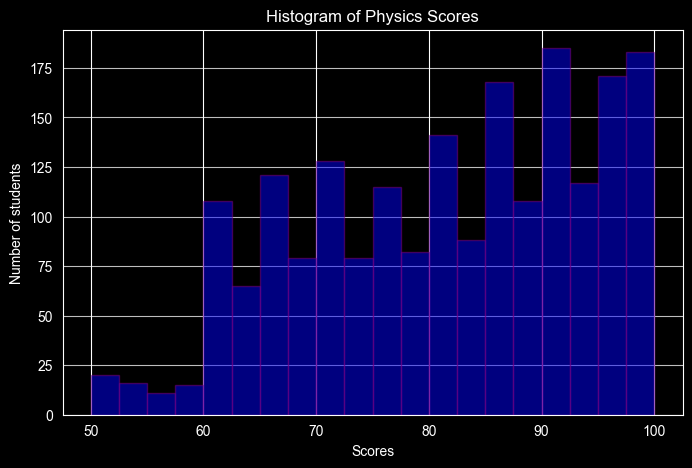

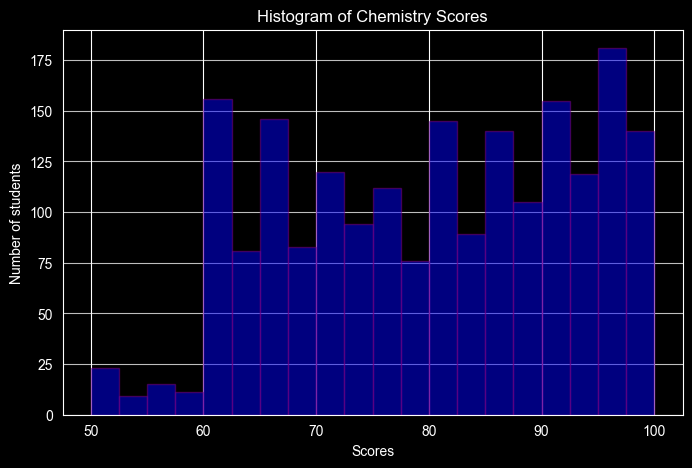

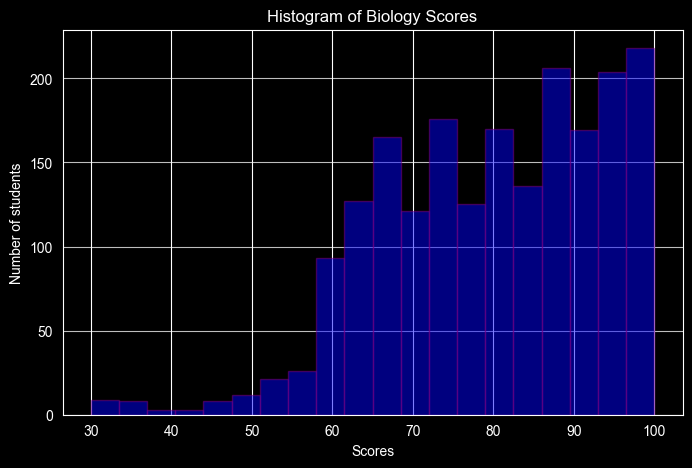

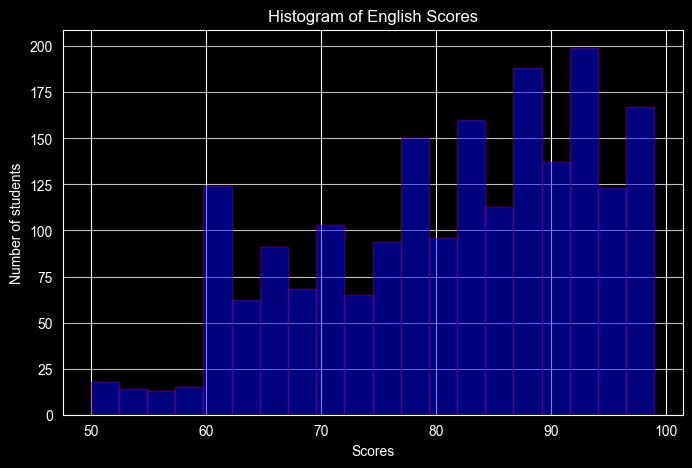

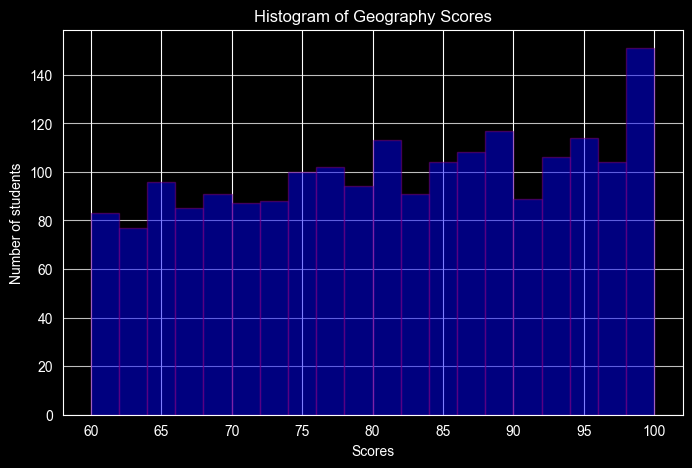

In [31]:
# Plot histograms for each subject to visualise the score distributions
subjects = df_scores.columns
for subject in subjects:
    plt.figure(figsize=(8, 5))
    plt.hist(df_scores[subject], alpha=0.5, bins=20, label=subject, edgecolor='purple', color='blue')
    subject_string = str.split(subject, "_")[0].capitalize()
    plt.title(f'Histogram of {subject_string} Scores')
    plt.xlabel('Scores')
    plt.ylabel('Number of students')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

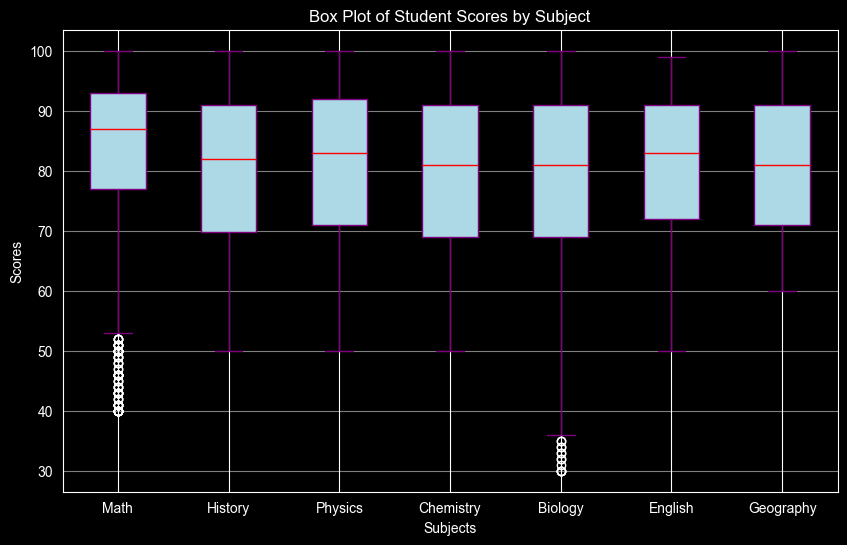

In [32]:
# Create a box plot to compare the score distributions across the subjects
subjects = df_scores.columns
pretty_subjects = [str.split(subject, "_")[0].capitalize() for subject in subjects]
plt.figure(figsize=(10, 6))
plt.boxplot([df_scores[subject] for subject in subjects],
            tick_labels=pretty_subjects,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='purple'),
            medianprops=dict(color='red'), whiskerprops=dict(color='purple'), capprops=dict(color='purple'))
plt.title('Box Plot of Student Scores by Subject')
plt.xlabel('Subjects')
plt.ylabel('Scores')
plt.grid(axis='y', alpha=0.5)
plt.show()

### Task 6: Correlation analysis between subjects

In [33]:
# Calculate the correlation matrix to understand the relationships between scores in different subjects

# This can be done using the corr() method of Pandas DataFrame
pandas_correlation_matrix = df_scores.corr()
pandas_correlation_matrix = pandas_correlation_matrix.round(8)
print(pandas_correlation_matrix)

                 math_score  history_score  physics_score  chemistry_score  \
math_score         1.000000       0.147247       0.115719         0.127131   
history_score      0.147247       1.000000       0.048478         0.121498   
physics_score      0.115719       0.048478       1.000000         0.126163   
chemistry_score    0.127131       0.121498       0.126163         1.000000   
biology_score      0.081298       0.088502       0.132280         0.119992   
english_score      0.134831       0.147193       0.054314         0.068341   
geography_score    0.049672       0.065751       0.103126         0.065430   

                 biology_score  english_score  geography_score  
math_score            0.081298       0.134831         0.049672  
history_score         0.088502       0.147193         0.065751  
physics_score         0.132280       0.054314         0.103126  
chemistry_score       0.119992       0.068341         0.065430  
biology_score         1.000000       0.074227     

In [34]:
# This can also be done using the np.corrcoef() method of NumPy on the NumPy array
numpy_correlation_matrix = np.corrcoef(scores_array, rowvar=False)
numpy_correlation_matrix = np.round(numpy_correlation_matrix, 8)
numpy_correlation_matrix

array([[1.        , 0.14724747, 0.11571874, 0.12713149, 0.08129806,
        0.13483078, 0.04967233],
       [0.14724747, 1.        , 0.04847843, 0.12149786, 0.08850197,
        0.14719288, 0.06575135],
       [0.11571874, 0.04847843, 1.        , 0.1261628 , 0.13227971,
        0.0543137 , 0.10312592],
       [0.12713149, 0.12149786, 0.1261628 , 1.        , 0.11999168,
        0.06834058, 0.06543008],
       [0.08129806, 0.08850197, 0.13227971, 0.11999168, 1.        ,
        0.07422691, 0.10652591],
       [0.13483078, 0.14719288, 0.0543137 , 0.06834058, 0.07422691,
        1.        , 0.07224979],
       [0.04967233, 0.06575135, 0.10312592, 0.06543008, 0.10652591,
        0.07224979, 1.        ]])

In [35]:
# Print the correlation matrix to understand the relationships between scores in different subjects
subjects = df_scores.columns

for i in range(len(subjects)):
    for j in range(i + 1, len(subjects)):
        print(f"{subjects[i]} ↔ {subjects[j]}:"
              f" {numpy_correlation_matrix[i, j]:.8f}")

math_score ↔ history_score: 0.14724747
math_score ↔ physics_score: 0.11571874
math_score ↔ chemistry_score: 0.12713149
math_score ↔ biology_score: 0.08129806
math_score ↔ english_score: 0.13483078
math_score ↔ geography_score: 0.04967233
history_score ↔ physics_score: 0.04847843
history_score ↔ chemistry_score: 0.12149786
history_score ↔ biology_score: 0.08850197
history_score ↔ english_score: 0.14719288
history_score ↔ geography_score: 0.06575135
physics_score ↔ chemistry_score: 0.12616280
physics_score ↔ biology_score: 0.13227971
physics_score ↔ english_score: 0.05431370
physics_score ↔ geography_score: 0.10312592
chemistry_score ↔ biology_score: 0.11999168
chemistry_score ↔ english_score: 0.06834058
chemistry_score ↔ geography_score: 0.06543008
biology_score ↔ english_score: 0.07422691
biology_score ↔ geography_score: 0.10652591
english_score ↔ geography_score: 0.07224979
